# **Exemplo de código em Python!**

In [ ]:
print('Hello World')

Hello World


# **Modelos de Redes Neurais**

# Perceptron

In [ ]:
#Biblioteca

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
#Carregar os dados
df = pd.read_csv("Telco-Customer-Churn.csv")

In [ ]:
#Selecionar as colunas relevantes
features = ["MonthlyCharges" , "Contract" , "OnlineSecurity" , "Churn"]
df = df[features]

In [ ]:
#Tratar valores faltantes
df = df.dropna()

In [ ]:
#Codificação de variáveis categóricas
label_encoders = {}
for col in ["Contract" , "OnlineSecurity" , "Churn"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [ ]:
#Separar variáveis independentes e dependente
X = df[["MonthlyCharges" , "Contract" , "OnlineSecurity"]]
y = df["Churn"].values

In [ ]:
#Normalizar os dados
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
#Divisão entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
#Impementação do Perceptron
class Perceptron:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def activation(self, x):
        return 1 if x >= 0 else 0

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.epochs):
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_pred = self.activation(linear_output)

                update = self.lr * (y[idx] - y_pred)
                self.weights += update * x_i
                self.bias += update

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.array([self.activation(x) for x in linear_output])

In [ ]:
#Treinar Modelo
perceptron = Perceptron(lr=0.01, epochs=1000)
perceptron.fit(X_train, y_train)

y_pred = perceptron.predict(X_test)

In [ ]:
#Avaliação do Modelo
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Acurácia: {accuracy:.4f}")
print("Matriz de Confusão: \n", conf_matrix)
print("Relatório de Classificação:\n", report)

Acurácia: 0.7132
Matriz de Confusão: 
 [[1342  197]
 [ 409  165]]
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.77      0.87      0.82      1539
           1       0.46      0.29      0.35       574

    accuracy                           0.71      2113
   macro avg       0.61      0.58      0.58      2113
weighted avg       0.68      0.71      0.69      2113



# Redes Neurais de Camada Unica

In [ ]:
# Biblioteca
import numpy as np

In [ ]:
# Função de ativação binária (passo)
def step(x):
  if x >= 0:
    return 1
  else:
    return 0

In [ ]:
# Treinamento do Perceptron
def treinar_perceptron(entradas, saidas, taxa_aprendizagem, epocas):
  # Inicializar pesos aleatoriamente
  pesos = np.random.rand(3)

  for epoca in range(epocas):
    for i in range(len(entradas)):
      # Calcular soma ponderada
      soma_ponderada = np.dot(entradas[i], pesos)

      # Calcular saída do perceptron
      saida = step(soma_ponderada)
      # Ajustar pesos com base no erro
      erro = saidas[i] - saida
      pesos += taxa_aprendizagem * erro * entradas[i]
  # Retornar os pesos atualizados
  return pesos

In [ ]:
# Exemplo de uso
entradas = np.array([
    [5.1, 3.5, 1.4],
    [4.9, 3.0, 1.4],
    [5.1, 3.6, 1.4],
    [6.4, 3.0, 1.7],
    [6.9, 3.1, 1.5],
    [5.7, 2.5, 1.3],
    [5.8, 2.7, 1.3],
])

In [ ]:
saidas = np.array([0, 0, 0, 1, 1, 2, 2])

taxa_aprendizagem = 0.1
epocas = 300

In [ ]:
# Treinar o perceptron and save the trained weights to the 'pesos' variable
pesos = treinar_perceptron(entradas, saidas, taxa_aprendizagem, epocas)

In [ ]:
# Treinar o perceptron
treinar_perceptron(entradas, saidas, taxa_aprendizagem, epocas)

array([ 36.14592468, -45.902519  ,  -8.11710675])

In [ ]:
# Classificar nova flor
nova_flor = np.array([5.4, 3.5, 1.5])
soma_ponderada = np.dot(nova_flor, pesos)
saida = step(soma_ponderada)

if saida == 0:
  print("Nova flor classificada como Íris")
elif saida == 1:
  print("Nova flor classificada como Lírio")
else:
  print("Nova flor classificada como Rosa")

Nova flor classificada como Lírio


# Redes Multicamadas

In [ ]:
# Bibliotecas
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Carregar o dataset de digitos
digits = load_digits()
X = digits.data
y = digits.target

In [ ]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Normalizar os dados
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Criar e treinar o MLP
mlp = MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42)

In [ ]:
# Fazer previsões no conjunto de teste
y_pred = mlp.predict(X_test)

In [ ]:
# Avaliar o modelo
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      0.96      0.98        28
           2       0.94      1.00      0.97        33
           3       0.97      0.94      0.96        34
           4       0.98      1.00      0.99        46
           5       0.96      0.96      0.96        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.97      0.97      0.97        30
           9       0.95      0.95      0.95        40

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360

Confusion Matrix:
 [[33  0  0  0  0  0  0  0  0  0]
 [ 0 27  1  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  1 32  0  1  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 45  1  0  0  1]


In [ ]:
# Visualizar alguns resultados
def plot_digits(X, y_true, y_pred=None):
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    for i, ax in enumerate(axes.flat):
        ax.imshow(X[i].reshape(8, 8), cmap="gray")
        if y_pred is not None:
            ax.set_title(f"True: {y_true[i]} \nPred: {y_pred[i]}")
        else:
            ax.set_title(f"True: {y_true[i]}")
        ax.axis("off")
    plt.show()

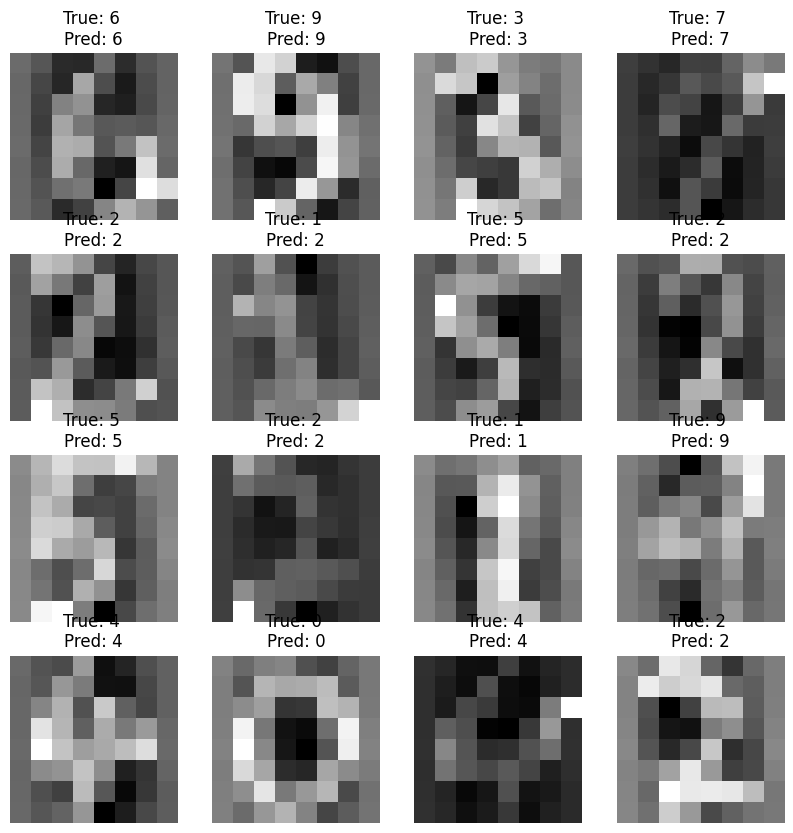

In [ ]:
# Mostrar alguns dígitos com suas previsões
plot_digits(X_test, y_test, y_pred)

# Redes Multicamadas Exemplo 2

In [ ]:
# Biblioteca
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Carregar o conjunto de dados Fashion MNIST
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Definir os nomes das classes
class_names = ["T-shirt/top" , "Calça" , "Pullover" , "Vestido" , "Casaco" ,
               "Sandália" , "Camisa" , "Tênis" , "Bolsa" , "Bota"]

In [ ]:
# Pré-processamento dos dados
train_images = train_images / 255.0
test_images = test_images / 255.0

In [ ]:
# Definir a arquitetura da rede neural
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),#Camada de entrada: achatamento da imagem em um vetor unidimensional
    keras.layers.Dense(128, activation="relu"),# Camada oculta com 128 neurônios e função de ativação ReLU
    keras.layers.Dense(10, activation="softmax")# Camada de saída com 10 neurônios (um para cada classe) e função de ativação softma
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Compilar o modelo
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [ ]:
# Treinar o modelo
model.fit(train_images, train_labels, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.7840 - loss: 0.6271
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.8646 - loss: 0.3816
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8779 - loss: 0.3342
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8856 - loss: 0.3093
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8954 - loss: 0.2844


In [ ]:
# Avaliar o modelo com os dados de teste
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("\nAcurácia do testet:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8684 - loss: 0.3695

Acurácia do testet: 0.866100013256073


In [ ]:
# Fazer previsões com o modelo treinado
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
# Função auxiliar para mostrar a imagem e a previsão correspondente
def plot_image(i, predictions_array, true_label, img):
    predictions_array, true_label, img = predictions_array[i], true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = "blue"
    else:
        color = "red"

    plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                         100 * np.max(predictions_array),
                                         class_names[true_label]),
                                         color=color)

In [ ]:
#Função auxiliar para mostrar o valor predito em formato de gráfico de barras
def plot_value_array(i, predictions_array, true_label):
    predictions_array, true_label = predictions_array[i], true_label[i]
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)

    thisplot[predicted_label].set_color("red")
    thisplot[true_label].set_color("blue")

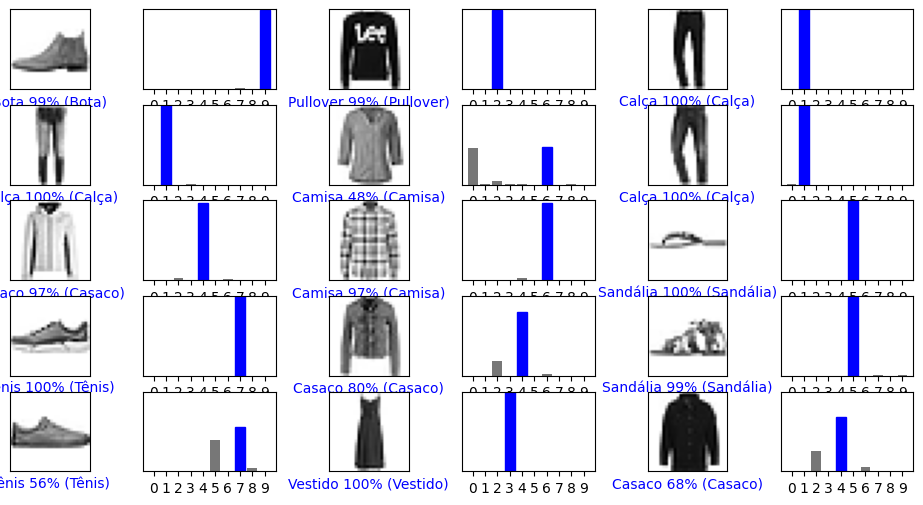

In [ ]:
# visualizar algumas previsões
num_rows = 5
num_cols = 3
num_images = num_rows * num_cols
plt.figure(figsize=(2 * 2 * num_cols, 2 * num_cols))
for i in range(num_images):
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
    plot_image(i, predictions, test_labels, test_images)
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
    plot_value_array(i, predictions, test_labels)
plt.show()

# **Modelos Transformers e LLM**

In [22]:
# Biblioteca

import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F

In [23]:
# Definir um dataset simples de exemplo
class SimpleDataset(Dataset):
  def __init__(self, texts, labels, tokenizer, max_length=128):
    self.texts = texts
    self.labels = labels
    self.tokenizer = tokenizer
    self.max_length = max_length

  def __len__(self):
    return len(self.texts)

  def __getitem__(self, idx):
    encoding = self.tokenizer(
                              self.texts[idx],
                              padding="max_length",
                              truncation=True,
                              max_length=self.max_length,
                              return_tensors="pt")
    return {
        'input_ids': encoding['input_ids'].squeeze(0),
        'attention_mask': encoding['attention_mask'].squeeze(0),
        'labels': torch.tensor(self.labels[idx], dtype=torch.long)
    }

In [24]:
# Criar tokenizer e modelo pré-treinado
model_name = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name, num_labels=2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [25]:
# Exemplo de textos e rótulos (0 = negativo, 1 = positivo)
texts = ["I love this product!", "This is the worst experience ever."]
labels = [1, 0, 1]

dataset = SimpleDataset(texts, labels, tokenizer)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

In [26]:
# Exemplo de treino simples
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
model.train()

for batch in dataloader:
  optimizer.zero_grad()
  outputs = model(input_ids=batch['input_ids'],
                  attention_mask=batch['attention_mask'],
                  labels=batch['labels'])
  loss = outputs.loss
  loss.backward()
  optimizer.step()
  print(f"Loss: {loss.item()}")

Loss: 0.707611083984375


In [16]:
# Teste com um novo texto

model.eval()
text = "The movie was absolutely wonderful!"
inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128)
# Teste com um novo texto

model.eval()
text = "The movie was absolutely wonderful!"
inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128)
outputs = model(**inputs)
preds = torch.argmax(F.softmax(outputs.logits, dim=1), dim=1)
print(f"Sentiment Prediction: {'Positive' if preds.item() == 1 else 'Negative'}")
#

Sentiment Prediction: Positive
